# CALIBER — reproducing all tables, intervals and figures

This notebook regenerates **every table, reported interval and figure** in the paper
*“CALIBER: A Reliability-Aware Information-Analytical System for Composite-Material Strength
Prediction with Cross-Dataset Validation”* (IJIES, Paper ID 20263531).

It is a thin wrapper around the command-line scripts in `src/`: each cell runs one script, so the
printed numbers are identical to those documented in `REPRODUCE.md` and reported in the manuscript.
All results are **mean ± SD over the ten leakage-free, composition-grouped splits** (evaluation seeds
0–9; primary split seed 42).

**Datasets** (in `data/`): Class A concrete (UCI), Class B steel-fibre-reinforced concrete (Mendeley),
Class C polymer (out-of-family stress test). The exact group membership of all eleven splits is in `splits/`.

**How to run:** `pip install -r requirements.txt`, then execute the cells top to bottom from the
repository root.

> Numbers are deterministic on the pinned versions in `requirements.txt`. Tiny last-digit differences
> across BLAS/OS builds are normal and change no conclusion.

## 0. Environment and helper

In [1]:
import subprocess, sys, platform, os
from IPython.display import Image, display, Markdown

print('Python', platform.python_version())
for pkg in ['numpy','pandas','scipy','sklearn','xgboost','lightgbm','matplotlib']:
    try:
        m = __import__(pkg); print(f'{pkg:12} {getattr(m, "__version__", "?")}')
    except Exception as e:
        print(f'{pkg:12} MISSING -> {e}')

print('\nDatasets :', sorted(f for f in os.listdir('data') if f.endswith(('.csv','.xlsx'))))
print('Splits   :', sorted(f for f in os.listdir('splits') if f.endswith('.json')))

def run(script):
    """Run a script in src/ and show its console output (the table)."""
    r = subprocess.run([sys.executable, script], capture_output=True, text=True)
    if r.returncode != 0:
        print('ERROR (stderr tail):\n', r.stderr[-2000:])
    print(r.stdout)

Python 3.12.3
numpy        2.4.4


pandas       3.0.2
scipy        1.17.1


sklearn      1.8.0
xgboost      3.2.0


lightgbm     4.6.0
matplotlib   3.10.8

Datasets : ['Concrete_Data.csv', 'Polymer_TPCM.xlsx', 'SFRC_Data_v1.xlsx']
Splits   : ['concrete_splits.json', 'sfrc_splits.json']


## Table 3 — predictive accuracy
Eight models on both classes, mean ± SD over ten splits. Class A (concrete) is scored on the training
partition; Class B (SFRC) on train + calibration (the conformal-core convention). **Expected:** the
gradient-boosting core reaches R² = 0.855 ± 0.027 (Class A) / 0.844 ± 0.061 (Class B), competitive with
XGBoost and LightGBM and well ahead of the linear and mean baselines.

In [2]:
run("src/table3_accuracy.py")

=== Table 3: predictive accuracy (10 splits, mean +/- SD) ===
Model                           Class A R2     Class A MAE      Class B R2     Class B MAE
Mean                        -0.006 +-0.007   13.46 +-0.61   -0.046 +-0.050   49.03 +-6.89 
Linear                       0.593 +-0.036    8.45 +-0.32    0.616 +-0.195   25.84 +-3.44 
SVR                          0.786 +-0.062    5.25 +-0.60    0.837 +-0.072   13.40 +-2.30 
RandomForest                 0.849 +-0.019    4.77 +-0.27    0.857 +-0.061   12.40 +-1.95 
GradBoost                    0.855 +-0.027    4.59 +-0.41    0.844 +-0.061   14.10 +-1.67 
XGBoost                      0.858 +-0.023    4.48 +-0.34    0.875 +-0.059   10.57 +-1.21 
LightGBM                     0.858 +-0.036    4.43 +-0.43    0.866 +-0.055   12.41 +-1.71 
MLP                          0.799 +-0.041    5.26 +-0.53    0.687 +-0.119   22.26 +-4.59 



## Table 4 — conformal coverage
Empirical coverage of the split / normalized / Mondrian conformal intervals at the 80 / 90 / 95 % nominal
levels, mean ± SD over ten splits. **Expected:** concrete split-conformal **78.4 ± 4.8 / 90.4 ± 4.1 /
95.6 ± 4.2**, and all SFRC variants near-nominal — conformal prediction transfers across both composite
classes with no change to the method.

In [3]:
run("src/table4_coverage.py")

=== Table 4: conformal coverage (10 splits, mean +/- SD) ===
Nominal        SFRC split       SFRC norm   SFRC Mondrian  Concrete split
80%            79.0 +-6.2      82.5 +-6.6      80.9 +-8.5      78.4 +-4.8
90%            88.7 +-5.1      91.2 +-3.7      92.2 +-3.1      90.4 +-4.1
95%            95.7 +-2.1      96.0 +-2.6      95.2 +-3.0      95.6 +-4.2



## Table 5 — novelty–error coupling criterion (ρNE)
The pre-deployment test at the heart of the paper: does the domain detector’s novelty score correlate
with the actual prediction error? **Expected** — Class A (concrete): ρNE = **+0.277 ± 0.115** (kNN) and
**+0.313 ± 0.095** (isolation forest), Holm-significant in 9/10 and 10/10 splits → **INFORMATIVE**;
Class B (SFRC): both detectors span zero → **WITHHELD**.

In [4]:
run("src/table5_novelty.py")

=== Table 5: novelty-error coupling criterion ===

Class A (concrete):
  rho_NE kNN  = +0.277 +- 0.115   Holm-significant 9/10
  rho_NE iso  = +0.313 +- 0.095   Holm-significant 10/10
  MAE near = 3.04    MAE far = 5.27  (primary)    error gap positive 9/10
  criterion verdict: INFORMATIVE

Class B (SFRC):
  rho_NE kNN  = +0.045 +- 0.149   Holm-significant 1/10
  rho_NE iso  = -0.034 +- 0.166   Holm-significant 1/10
  MAE near = 13.66    MAE far = 14.54  (ten-split mean)    error gap positive 5/10
  criterion verdict: WITHHELD (coupling not demonstrated)



## Section 4.1 — robustness to the choice of core
The reviewer asked whether the reliability conclusions depend on the gradient-boosting core, since random
forest is locally better on SFRC. Re-running the full reliability analysis on SFRC with a **random-forest
core** leaves the conclusions unchanged: coverage stays near-nominal and the domain detector stays
uninformative (both ρNE span zero). The findings are core-agnostic.

In [5]:
run("src/bestcore_rf.py")

=== Section 4.1: RF-core verification on SFRC (10 splits) ===
  split-conformal coverage:
     80%: 81.1 +- 8.9
     90%: 90.0 +- 4.5
     95%: 94.1 +- 3.5
  rho_NE kNN = +0.13 +- 0.12   iso = -0.09 +- 0.18  (both span zero -> uninformative, as with GB core)



## Section 5.2 — random vs grouped splitting
Direct demonstration that the composition-grouped split is *why* CALIBER reports lower (honest) accuracy
than studies using random record-level splits. **Expected** (concrete, same core): random R² =
**0.909 ± 0.012** vs grouped **0.855 ± 0.027** (Welch p < 0.001) — the higher figures reported elsewhere
are a leakage artefact.

In [6]:
run("src/random_vs_grouped.py")

=== Section 5.2: random vs grouped (train-only core) ===
CONCRETE  random R2 = 0.909 +- 0.012  MAE = 3.42
          grouped R2 = 0.855 +- 0.027  MAE = 4.59   (Welch p = 1.23e-04)
SFRC      random R2 = 0.897 +- 0.030   grouped R2 = 0.774 +- 0.083



## Class C — polymer out-of-family stress test
A third, non-cementitious dataset added at the reviewer’s request, framed honestly as an out-of-family
stress test. It shows the largest leakage gap (grouped R² ≈ 0 vs random R² ≈ 0.99) and a genuine
limitation (conformal under-coverage ≈ 87 % at the 95 % level under extreme extrapolation), with ρNE
behaving within its stated power limits on only 32 formulation groups.

In [7]:
run("src/classC_polymer.py")

=== Class C (polymer): 420 specimens, 32 formulation groups, 26 features; target mean 713 MPa, SD 506 MPa ===

-- leakage: random vs grouped (GB core, 10 splits) --
   grouped: R2 = +0.027 +- 1.931
   random : R2 = +0.994 +- 0.002

-- split-conformal coverage under extrapolation (10 splits) --
   80%: 76 +- 23
   90%: 82 +- 19
   95%: 87 +- 13

-- novelty-error coupling (deployed train+cal core, test set) --
   rho_NE kNN = +0.29 +- 0.39   iso = +0.23 +- 0.33
   MAE near = 94   far = 230 MPa   gap positive 9/10
   -> coupling positive but, on 32 groups, across-split interval spans zero: SUGGESTIVE, not established.



## Figures
Regenerate the four manuscript figures from the same computations. Figure 1 is the system architecture;
Figures 2–4 are data-driven (coverage, feature importance, cross-class comparison) and share their numbers
with Tables 4, 5 and 3. Each is rendered at its placement size with 10-pt lettering, no outer border, per
IJIES format.

**Figure 1 — layered architecture**

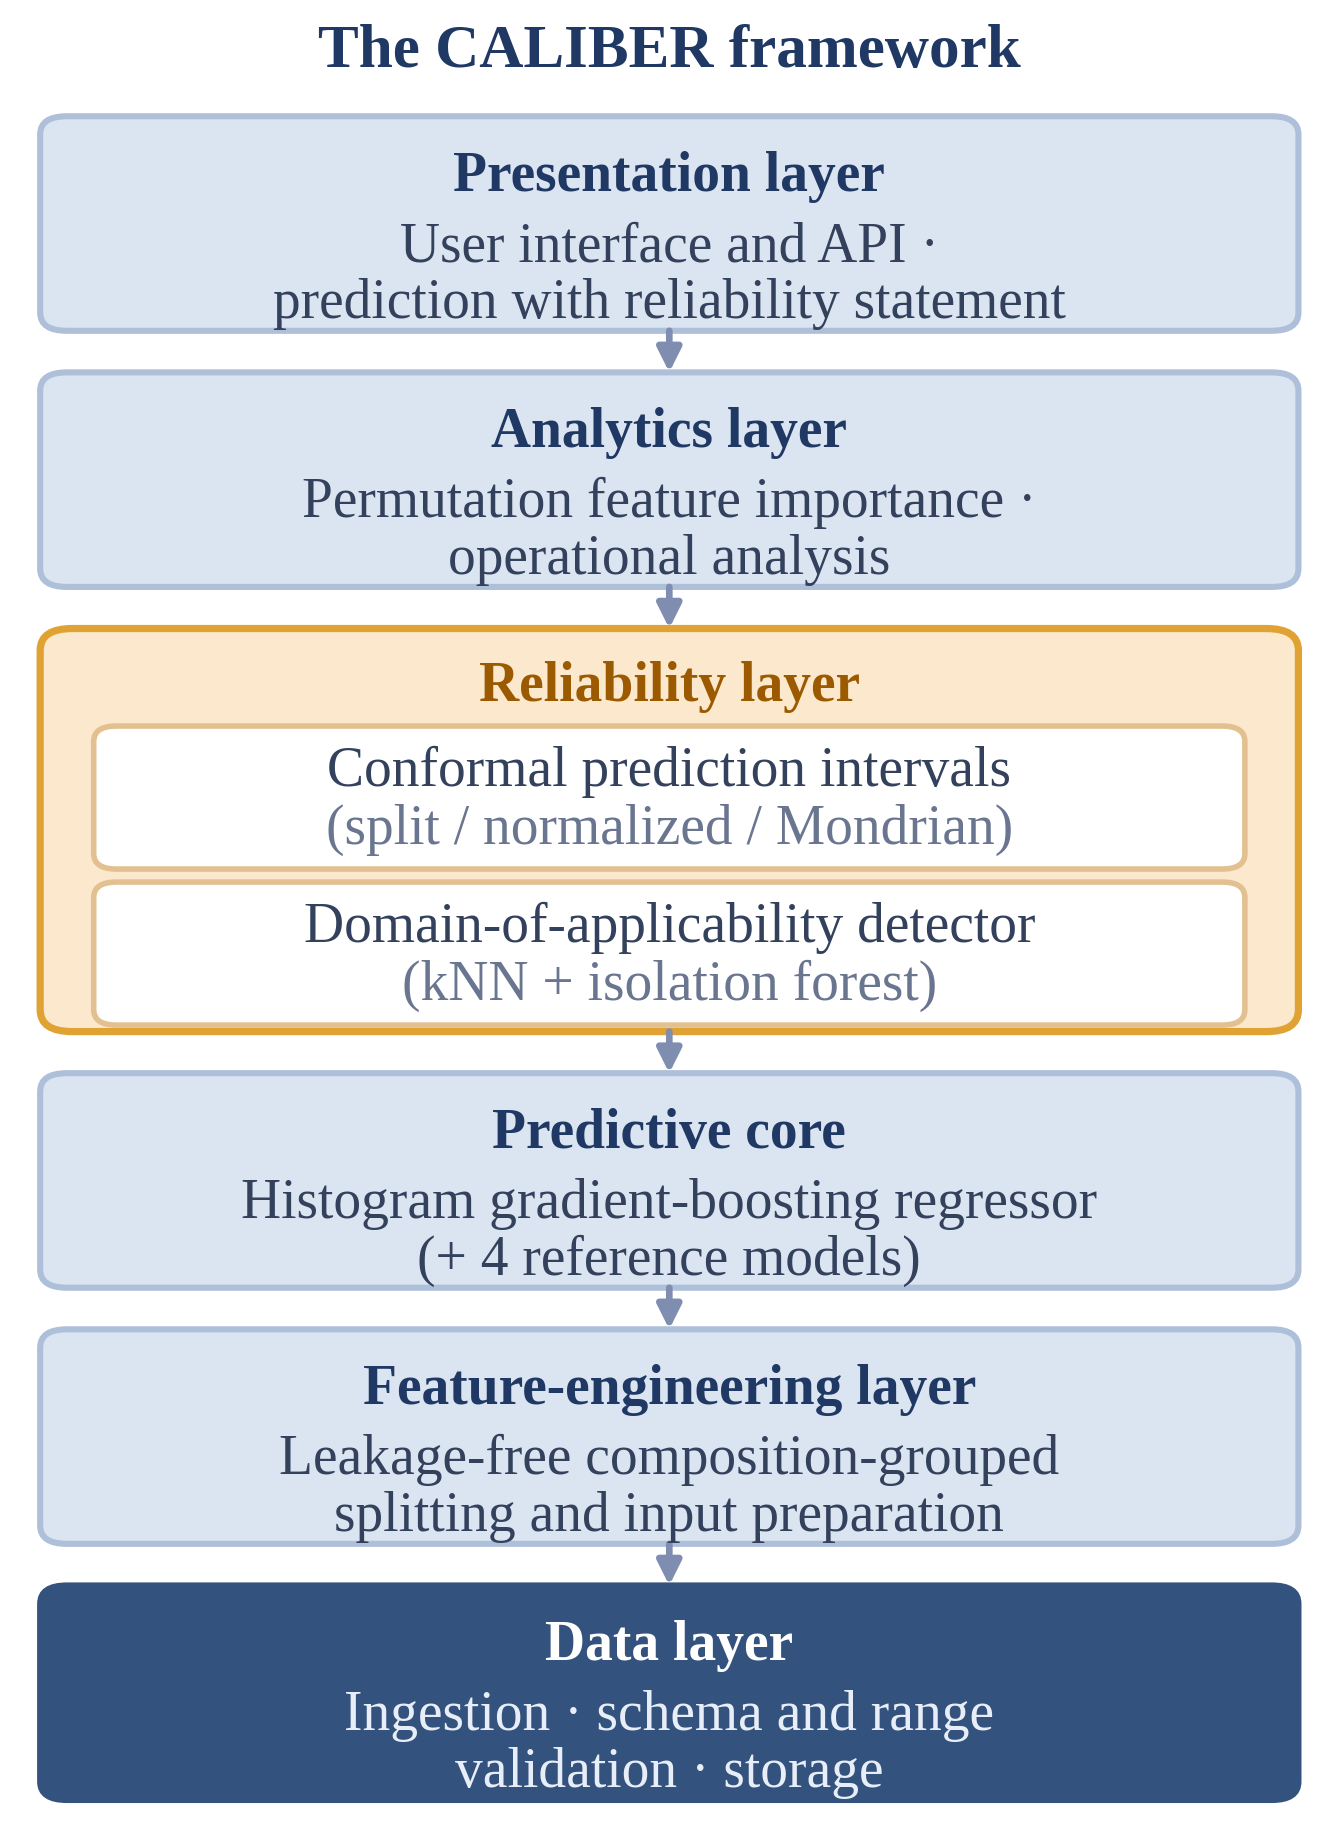

**Figure 2 — conformal interval coverage**

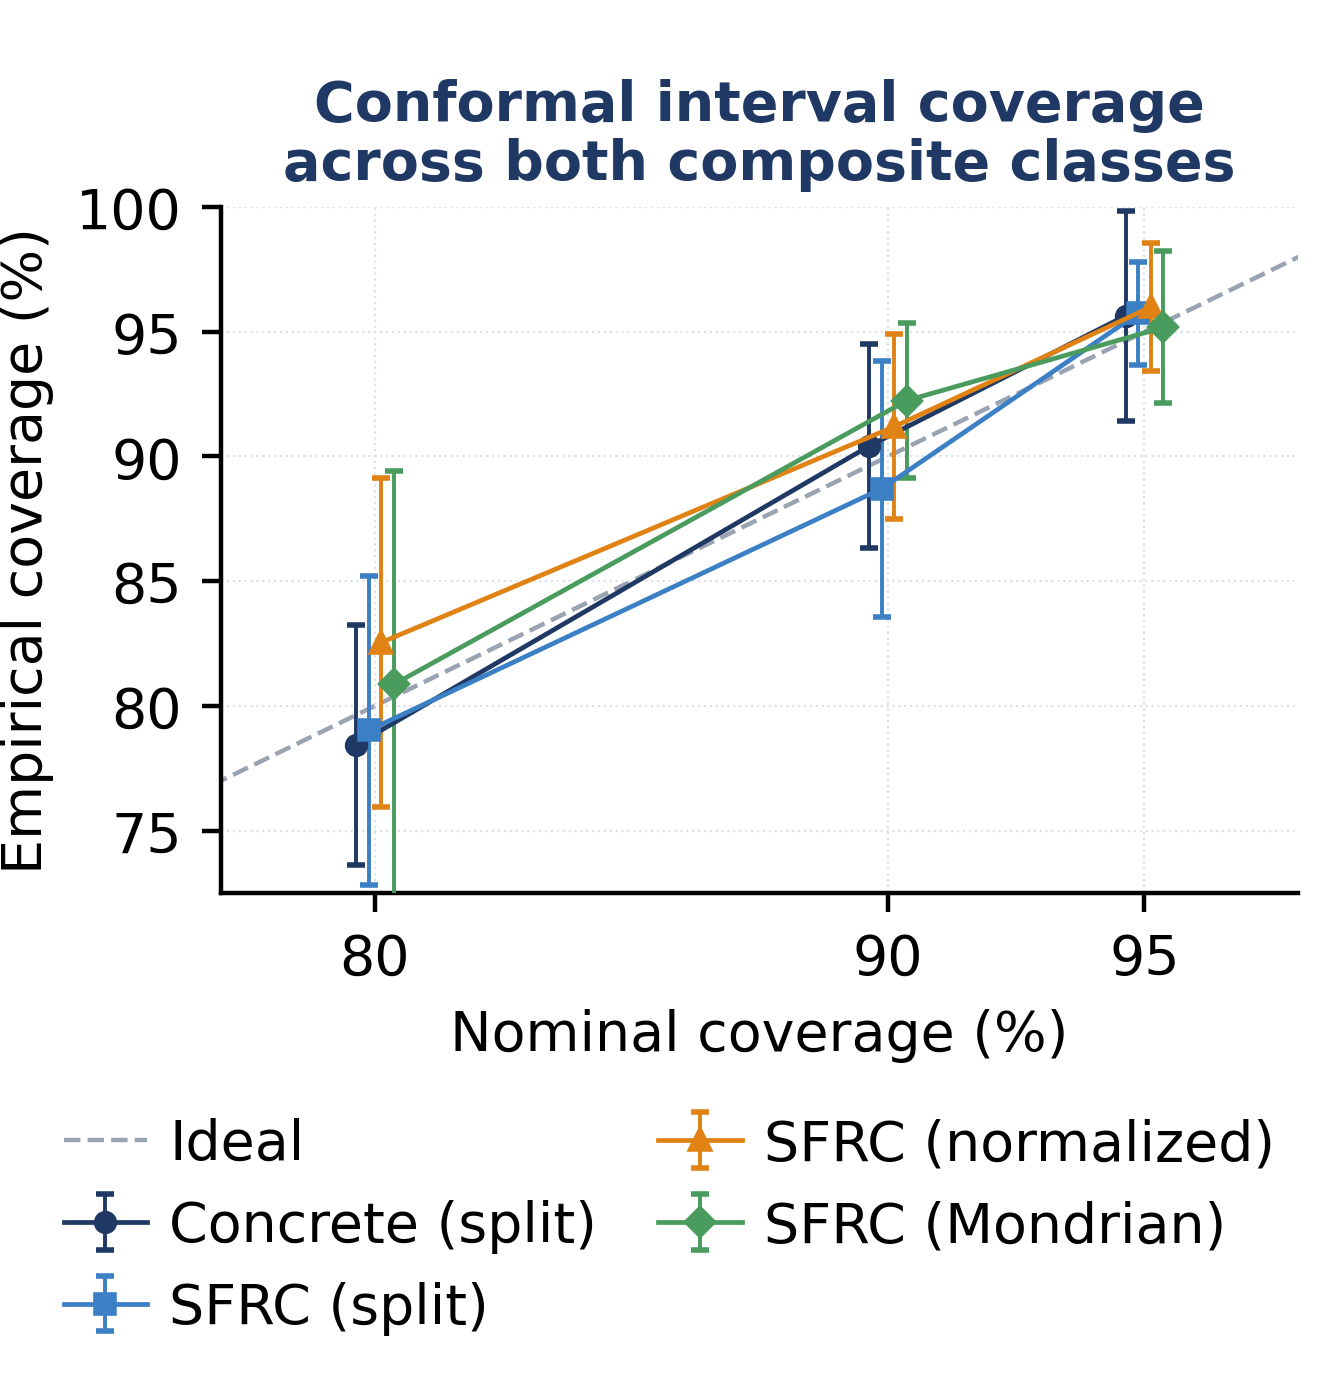

**Figure 3 — permutation feature importance (SFRC core)**

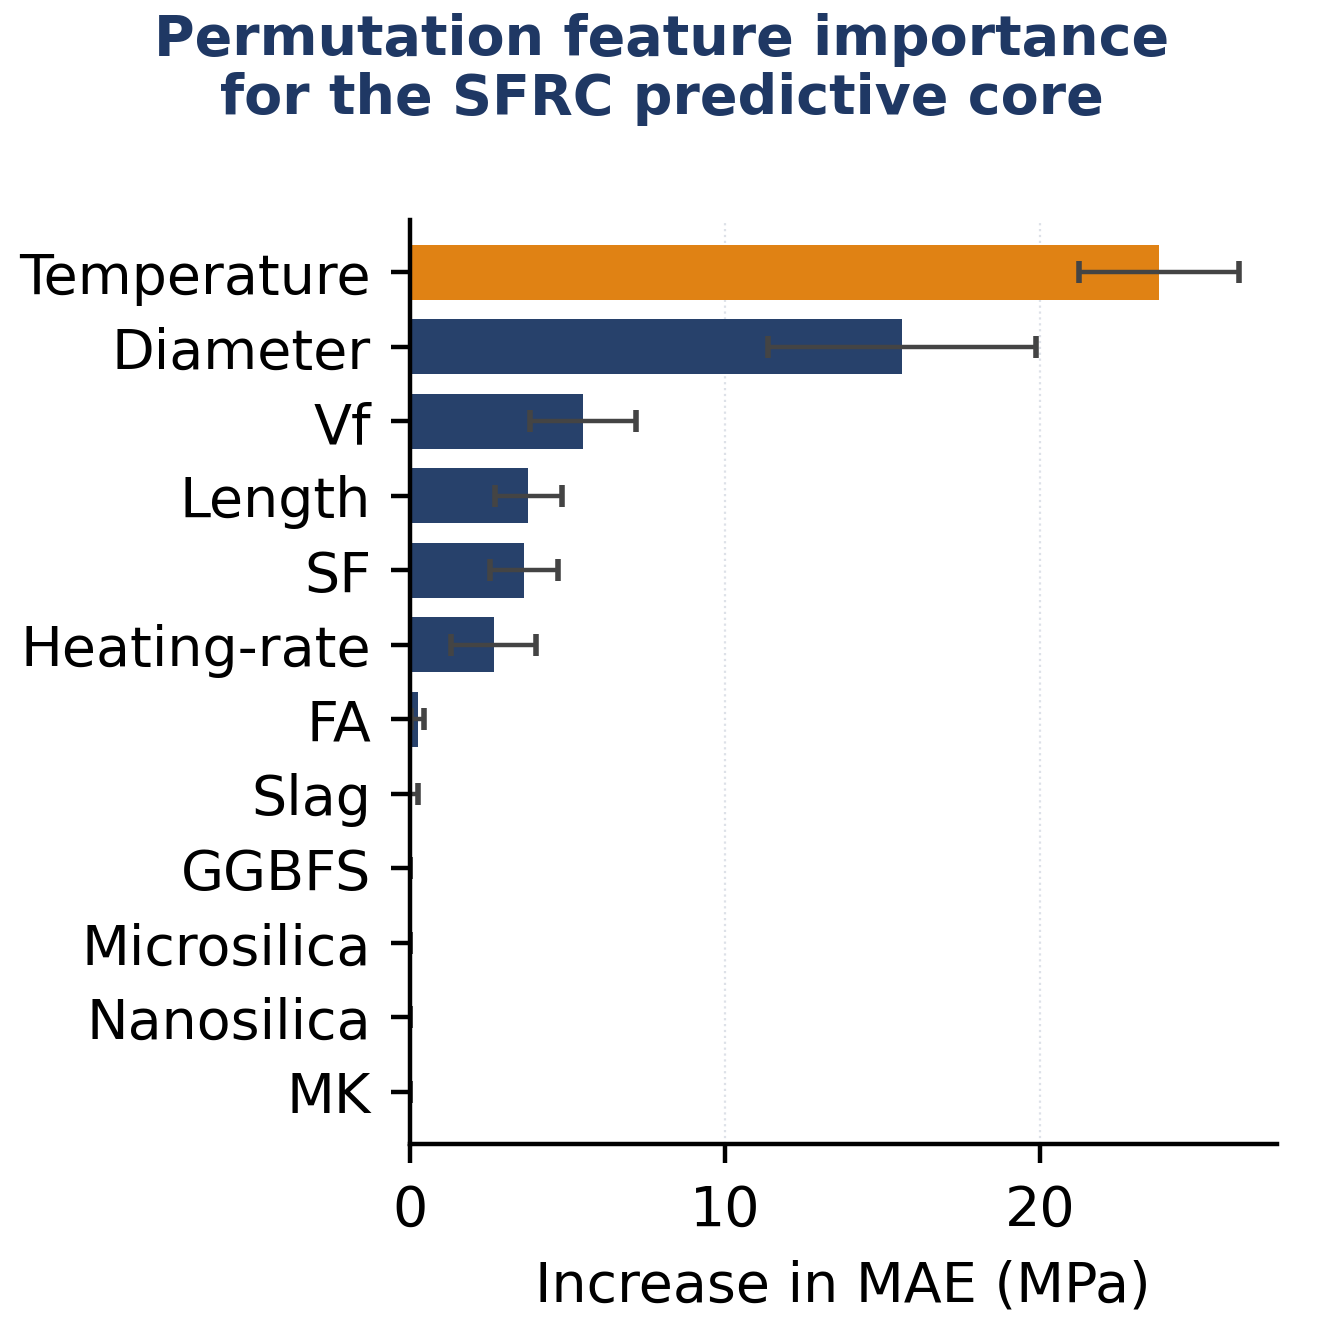

**Figure 4 — cross-class comparison**

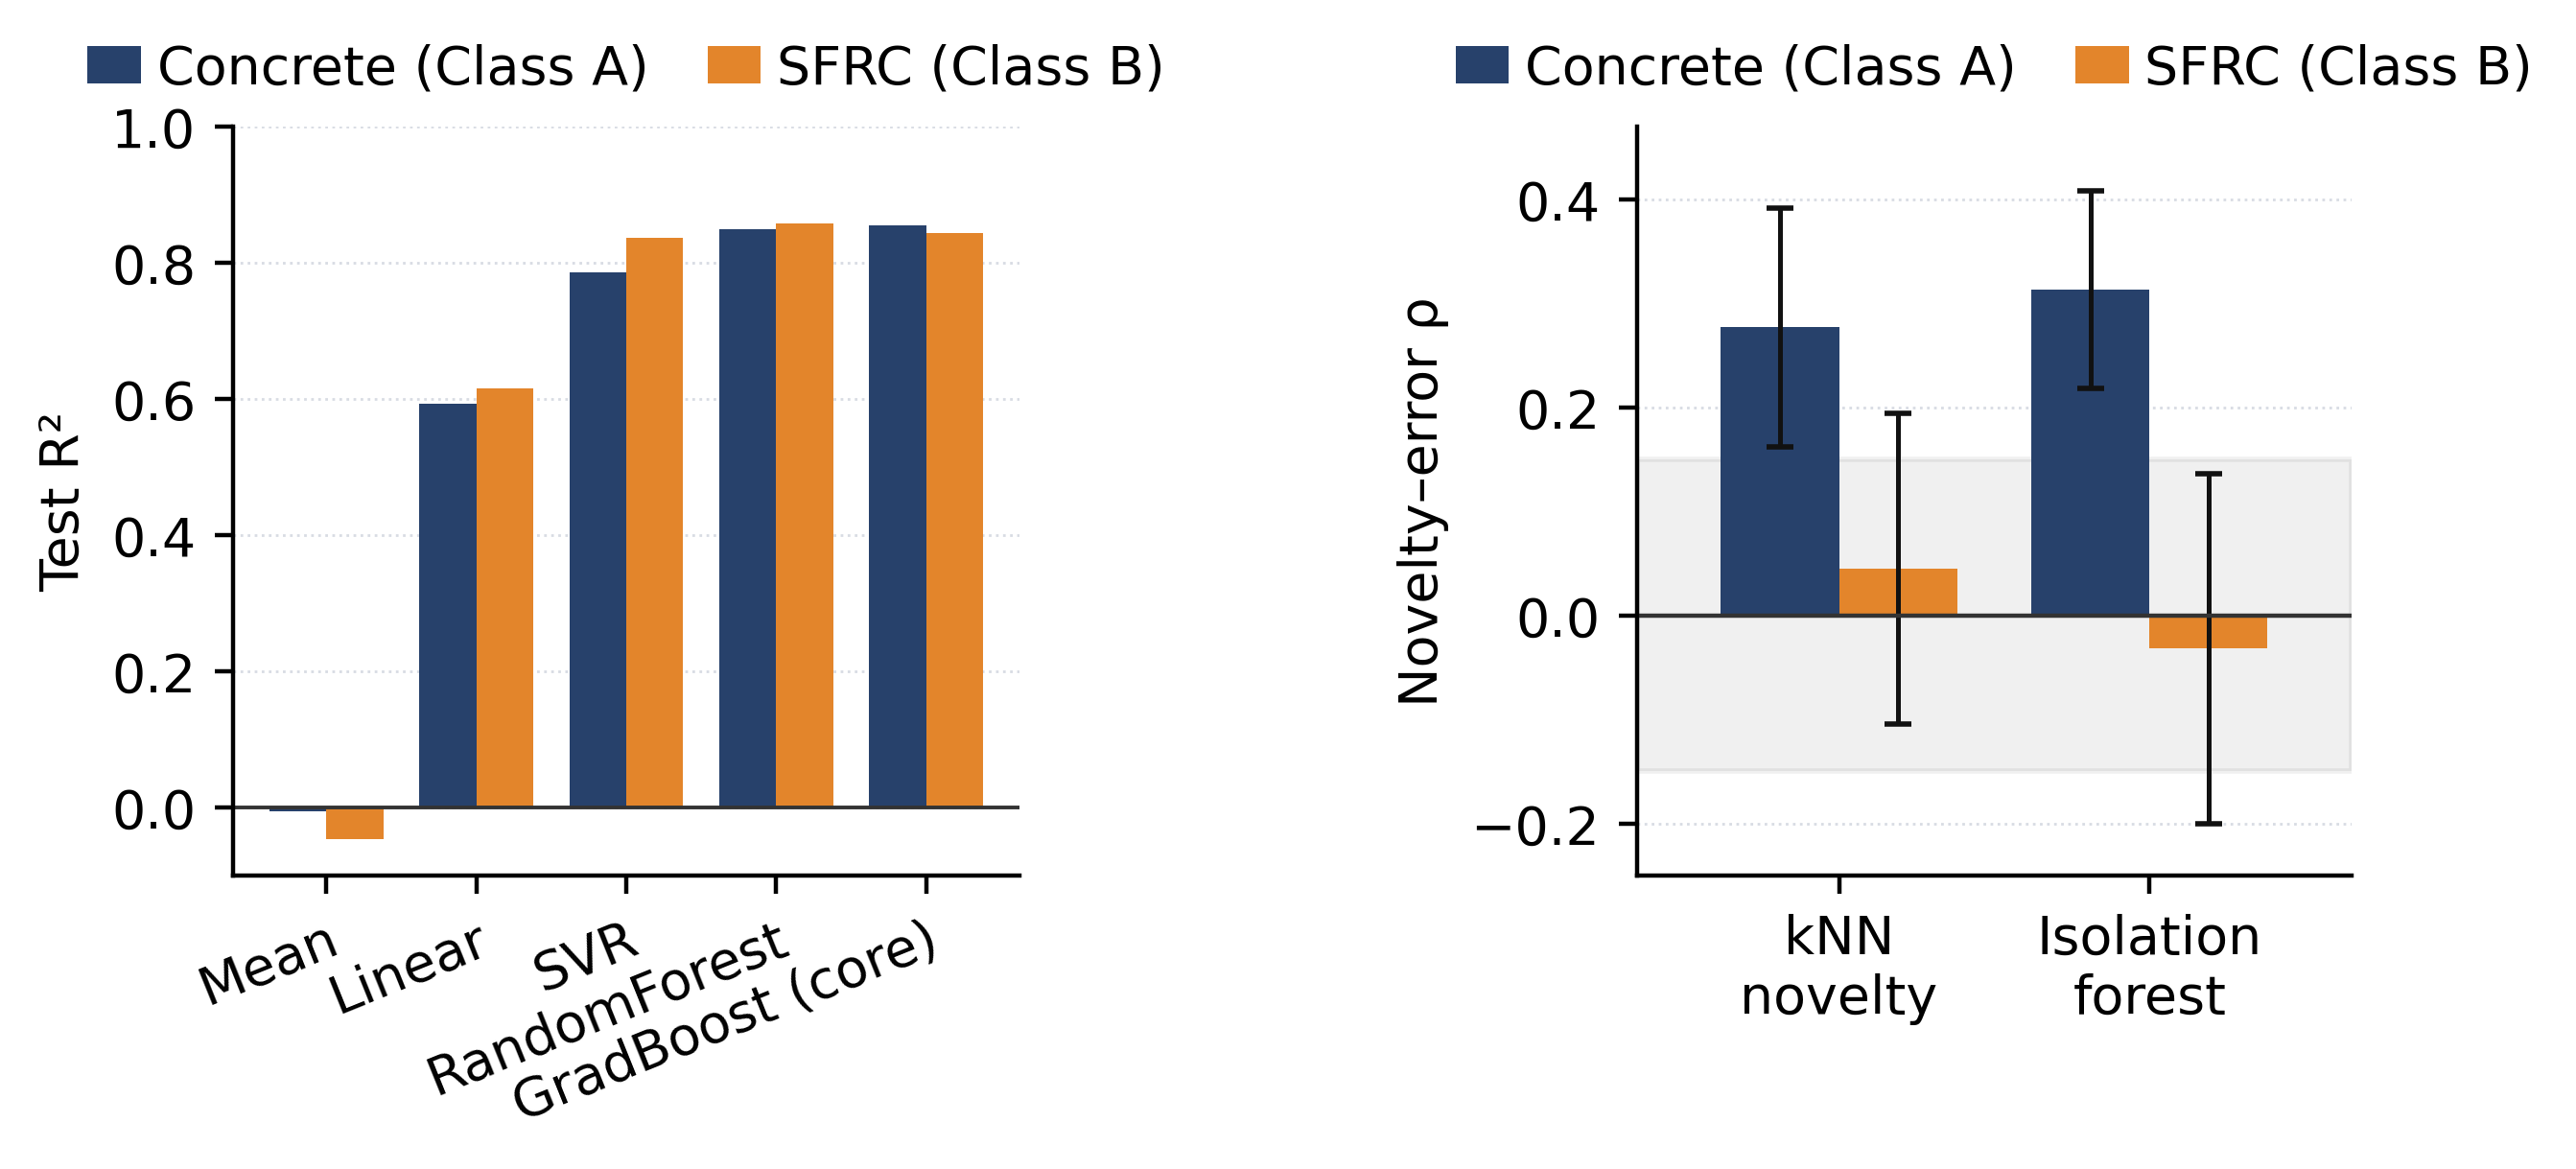

In [8]:
for s in ['figure1_architecture.py','figure2_coverage.py','figure3_importance.py','figure4.py']:
    subprocess.run([sys.executable, s], cwd='src', check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

figs = [('Figure 1 — layered architecture', 'src/figure1.png'),
        ('Figure 2 — conformal interval coverage', 'src/figure2.png'),
        ('Figure 3 — permutation feature importance (SFRC core)', 'src/figure3.png'),
        ('Figure 4 — cross-class comparison', 'results/figure4.png')]
for title, path in figs:
    display(Markdown(f'**{title}**')); display(Image(path))

## Summary
Every table, reported interval and figure above is regenerated from the committed datasets, split
identifiers, seeds and hyperparameters — nothing is hard-coded. For the command-line equivalent and the
full expected-output reference see **`REPRODUCE.md`**; for the exact hyperparameters and seeds see
**`hyperparameters.md`**.